# Checking for GPU

In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
 raise SystemError('GPU device not found')
print('GPU found at: {}'.format(device_name))

GPU found at: /device:GPU:0


# Necessary Imports

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from wordcloud import WordCloud
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Understanding Analysis and Cleaning

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/AmazonBookReview/kindle_review.csv') # Reading the dataset using pandas

In [ ]:
# Shuffling the dataset
train = train.sample(frac=1).reset_index(drop=True)

# Calculating the storage of each set
total_size = len(train)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

# Dataset is splitted into train, val, and test sets
train_set = train[:train_size]
val_set = train[train_size:train_size + val_size]
test_set = train[train_size + val_size:]

# DIsplaying the sizes of each set
print("Train set size:", len(train_set))
print("Validation set size:", len(val_set))
print("Test set size:", len(test_set))

Train set size: 8400
Validation set size: 1800
Test set size: 1800


In [ ]:
# #Data Understanding, Analysis and Cleaning
# train = pd.read_csv("/content/drive/MyDrive/IMDB Dataset/train.csv")
# test = pd.read_csv("/content/drive/MyDrive/IMDB Dataset/test.csv")
# valid = pd.read_csv("/content/drive/MyDrive/IMDB Dataset/val.csv")

In [ ]:

train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8400 entries, 0 to 8399
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  8400 non-null   int64 
 1   rating      8400 non-null   int64 
 2   reviewText  8400 non-null   object
 3   summary     8399 non-null   object
dtypes: int64(2), object(2)
memory usage: 262.6+ KB


In [ ]:


train_set.head(10)

,Unnamed: 0,rating,reviewText,summary
0,954,4,You'll rethink your take on vamps after readin...,Attention Vamp Lovers: Redeemer is Decidedly ...
1,10217,3,short and to the point. writing was ok and the...,just ok
2,11215,4,Willow Gregory had cut loose after spending he...,Miss Firecracker
3,7842,1,Not really my thing a friend brought it on my ...,yeah didnt really like it
4,11452,1,My review is based solely on the first short s...,Laughable
5,9627,5,Mind mapping is a very valuable process if you...,Visually Stimulating note-taking
6,4414,4,slow at first but totally suspenseful to the v...,Surprise!
7,7910,4,I had been looking for this story since it's B...,Enjoyed This
8,8162,5,I enjoyed the subtle way she wrote out the cha...,Great story
9,10428,3,My friend recommended this book to me because ...,SO weird!


In [ ]:

test_set.head(10)

,Unnamed: 0,rating,reviewText,summary
10200,11940,1,Atticus has walked the earth for a millennium ...,Painful as a Bus Crash
10201,3553,2,This was a very hard book to finish. I skipped...,Not what I expected!
10202,4199,3,Well I spent 80% of my time tilting my head li...,Hmm
10203,3758,3,I thought that this was a bit predictable. But...,So-so
10204,10256,5,I love Gena Showalter books. Even her short st...,Love Gena Showalter Books!!
10205,11381,3,More short stories with a Southern flavor by v...,"""Okay"" says it all"
10206,4836,1,His 'guardian' never did. The whole book seeme...,"Weak, like the guardian"
10207,8641,2,The synopsis definitely caught my interest and...,not quite what I'd hoped it would be
10208,11039,4,I pondered buying my ebook reader three years ...,It could happen
10209,8303,1,"Rather dull. And this box story, what an idiot...",Not so sweet


In [ ]:

def review_text_preprocessed(reviewText):
    review = re.sub(r'[^\w\s]','',reviewText)
    review = review.lower()
    review = [w for w in review.split(' ') if w not in stopwords.words('english')]
    review = [WordNetLemmatizer().lemmatize(token) for token in review]
    review = [WordNetLemmatizer().lemmatize(token,pos='v') for token in review]
    review = " ".join(review)
    return review

train_set['reviewText'] = train_set['reviewText'].apply(lambda x: review_text_preprocessed(x))
val_set['reviewText'] = val_set['reviewText'].apply(lambda x: review_text_preprocessed(x))
test_set['reviewText'] = test_set['reviewText'].apply(lambda x: review_text_preprocessed(x))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
<ipython-input-10-4b3279492a71>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_set['reviewText'] = train_set['reviewText'].apply(lambda x: Preprocessing(x))
<ipython-input-10-4b3279492a71>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_set['reviewText'] = val_set['reviewText'].apply(lambda x: Preprocessing(x))
<ipython-in

In [ ]:
# Assign sentiment based on rating: 1 if rating > 3 else 0.

train_set['sentiment'] = train_set['rating'].apply(lambda x: 1 if x > 3 else 0)
test_set['sentiment'] = test_set['rating'].apply(lambda x: 1 if x > 3 else 0)
val_set['sentiment'] = val_set['rating'].apply(lambda x: 1 if x > 3 else 0)


<ipython-input-11-250ac72bcfb1>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_set['sentiment'] = train_set['rating'].apply(lambda x: 1 if x > 3 else 0)
<ipython-input-11-250ac72bcfb1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set['sentiment'] = test_set['rating'].apply(lambda x: 1 if x > 3 else 0)
<ipython-input-11-250ac72bcfb1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [ ]:

train_set.drop(columns=['rating'], inplace=True)
test_set.drop(columns=['rating'], inplace=True)
val_set.drop(columns=['rating'], inplace=True)

<ipython-input-12-d6882bfa8208>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set.drop(columns=['rating'], inplace=True)
<ipython-input-12-d6882bfa8208>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_set.drop(columns=['rating'], inplace=True)


In [ ]:
train_set.head(10)

,Unnamed: 0,rating,reviewText,summary,sentiment
0,954,4,youll rethink take vamp read provocative fresh...,Attention Vamp Lovers: Redeemer is Decidedly ...,1
1,10217,3,short point write ok sex steamy short like nee...,just ok,0
2,11215,4,willow gregory cut loose spend last year miss ...,Miss Firecracker,1
3,7842,1,really thing friend bring kindle give read was...,yeah didnt really like it,0
4,11452,1,review base solely first short story could for...,Laughable,0
5,9627,5,mind map valuable process know use try give co...,Visually Stimulating note-taking,1
6,4414,4,slow first totally suspenseful end glad stick ...,Surprise!,1
7,7910,4,look story since book two king prey series als...,Enjoyed This,1
8,8162,5,enjoy subtle way write character push story we...,Great story,1
9,10428,3,friend recommend book buy kindle fire oh goodn...,SO weird!,0


In [ ]:
test_set.head()


,Unnamed: 0,reviewText,summary,sentiment
10200,11940,atticus walk earth millennium long search one ...,Painful as a Bus Crash,0
10201,3553,hard book finish skip many page get entire ch...,Not what I expected!,0
10202,4199,well spend 80 time tilt head like dog listen s...,Hmm,0
10203,3758,think bite predictable wasnt bad would read fr...,So-so,0
10204,10256,love gena showalter book even short story disp...,Love Gena Showalter Books!!,1


In [ ]:
val_set.head()

,Unnamed: 0,reviewText,summary,sentiment
8400,11850,relatively fast read rich older brother think ...,Lighthearted Romance,0
8401,1417,think worth read big fan novella form characte...,Just the introduction...,0
8402,6588,absolutely enjoy entire series right passion e...,So hot!,1
8403,7519,horrible book ever misfortune openingbought ki...,Soo Horrible,0
8404,87,enjoy book end think author could little desc...,Good Read,0


In [ ]:
# Count the number of reviews with each sentiment label
sentiment_counts = train_set['sentiment'].value_counts()

# Print the sentiment counts
print(sentiment_counts)


sentiment
0    4237
1    4163
Name: count, dtype: int64


In [ ]:
# Extract the review texts and sentiment labels from the train, valid, and test dataframes
train_x = train_set['reviewText'] 
valid_x = val_set['reviewText']   
test_x = test_set['reviewText']  
train_y = train_set['sentiment'] 
valid_y = val_set['sentiment'] 
test_y = test_set['sentiment'] 


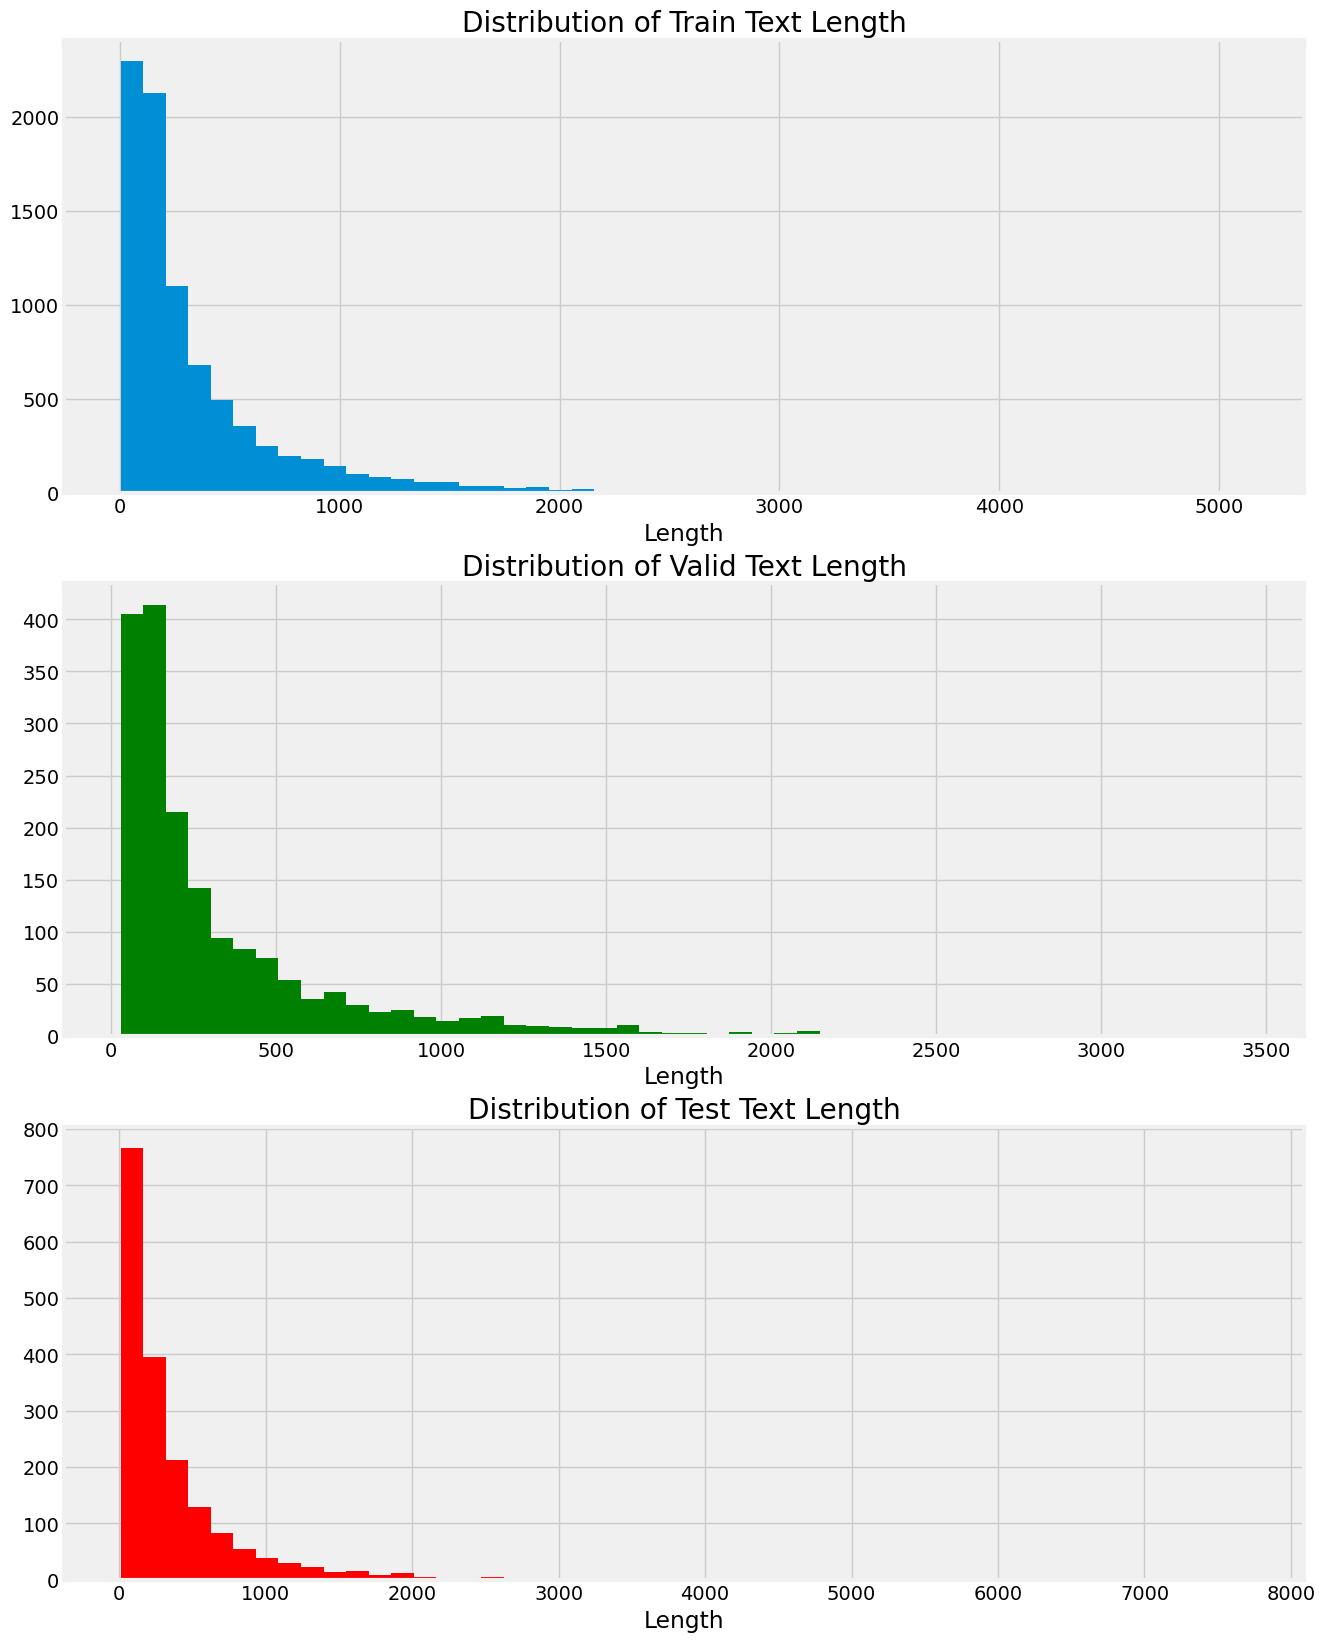

In [ ]:
import matplotlib.pyplot as plt

# Setting the figure size and style
plt.figure(figsize=(16, 20))
plt.style.use('fivethirtyeight')

# Creating the first subplot for the train data
plt.subplot(3, 1, 1)
train_len = [len(l) for l in train_x]
plt.hist(train_len, bins=50)
plt.title('Distribution of Train Text Length')
plt.xlabel('Length')

# Creating the second subplot for the valid data
plt.subplot(3, 1, 2)
valid_len = [len(l) for l in valid_x]
plt.hist(valid_len, bins=50, color='green')
plt.title('Distribution of Valid Text Length')
plt.xlabel('Length')

# Creating the third subplot for the test data
plt.subplot(3, 1, 3)
test_len = [len(l) for l in test_x]
plt.hist(test_len, bins=50, color='red')
plt.title('Distribution of Test Text Length')
plt.xlabel('Length')


plt.show()


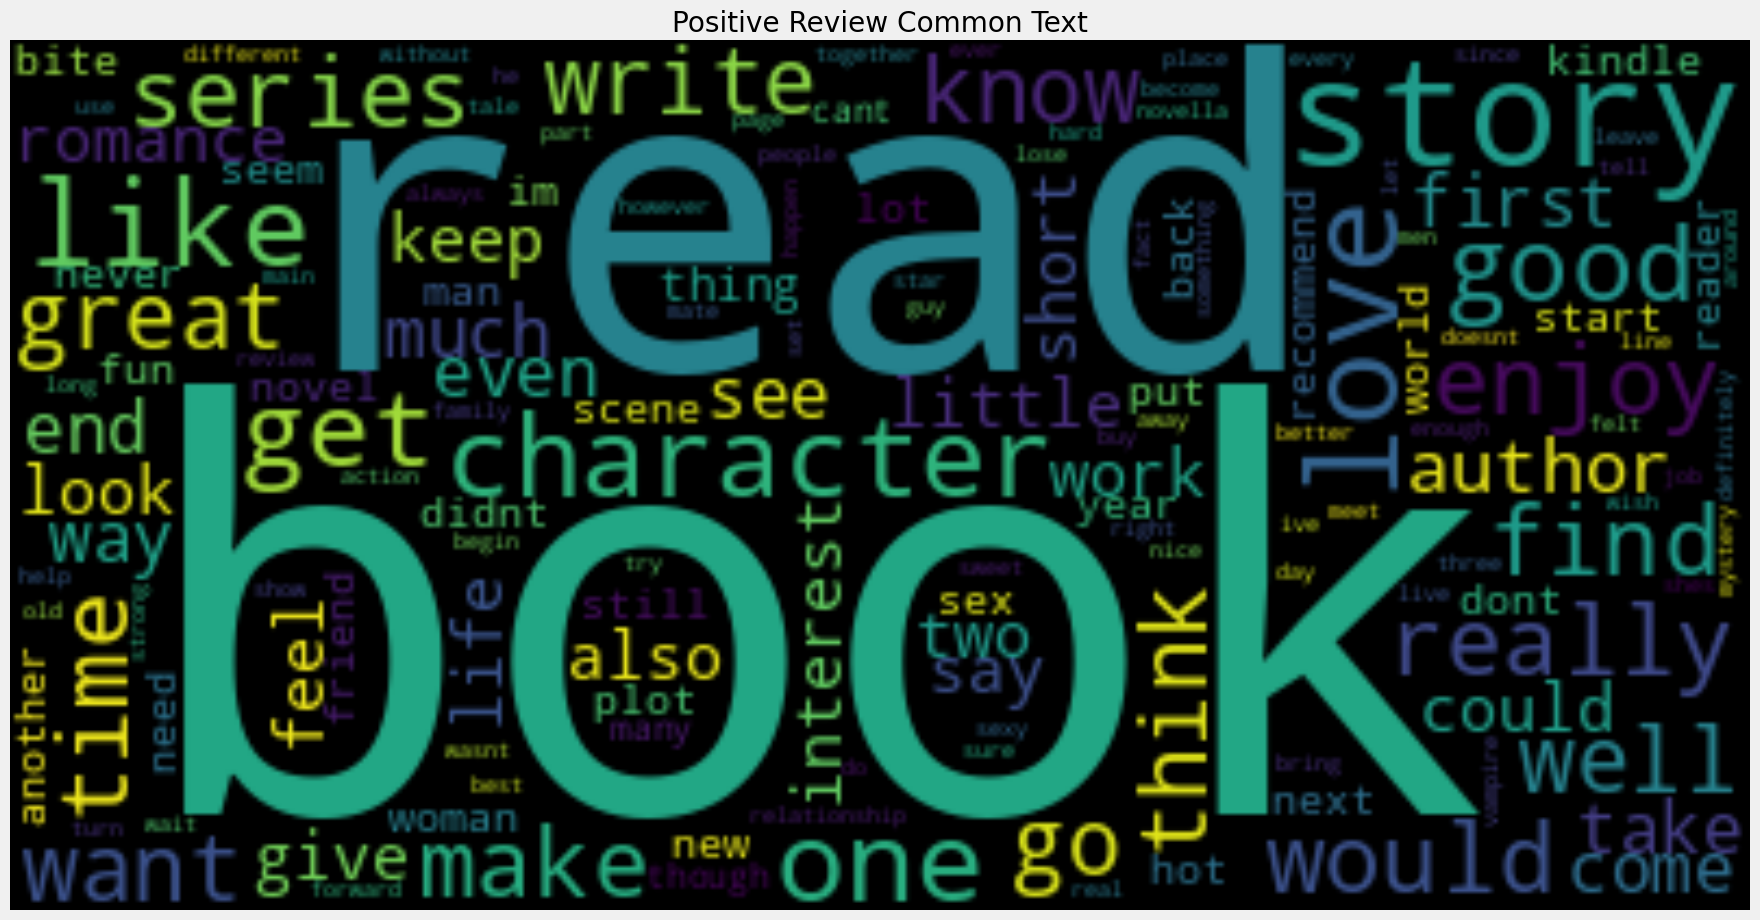

In [ ]:
# Set the figure size
plt.figure(figsize=(20, 20))

# Get the frequency distribution of words in positive reviews
pos_freq = FreqDist(' '.join(train_set[train_set['sentiment'] == 1].reviewText).split(' '))

# Generate a word cloud from the frequency distribution
wc = WordCloud().generate_from_frequencies(frequencies=pos_freq)

# Display the word cloud
plt.imshow(wc, interpolation='bilinear')
plt.title('Positive Review Common Text')
plt.axis('off')
plt.show()

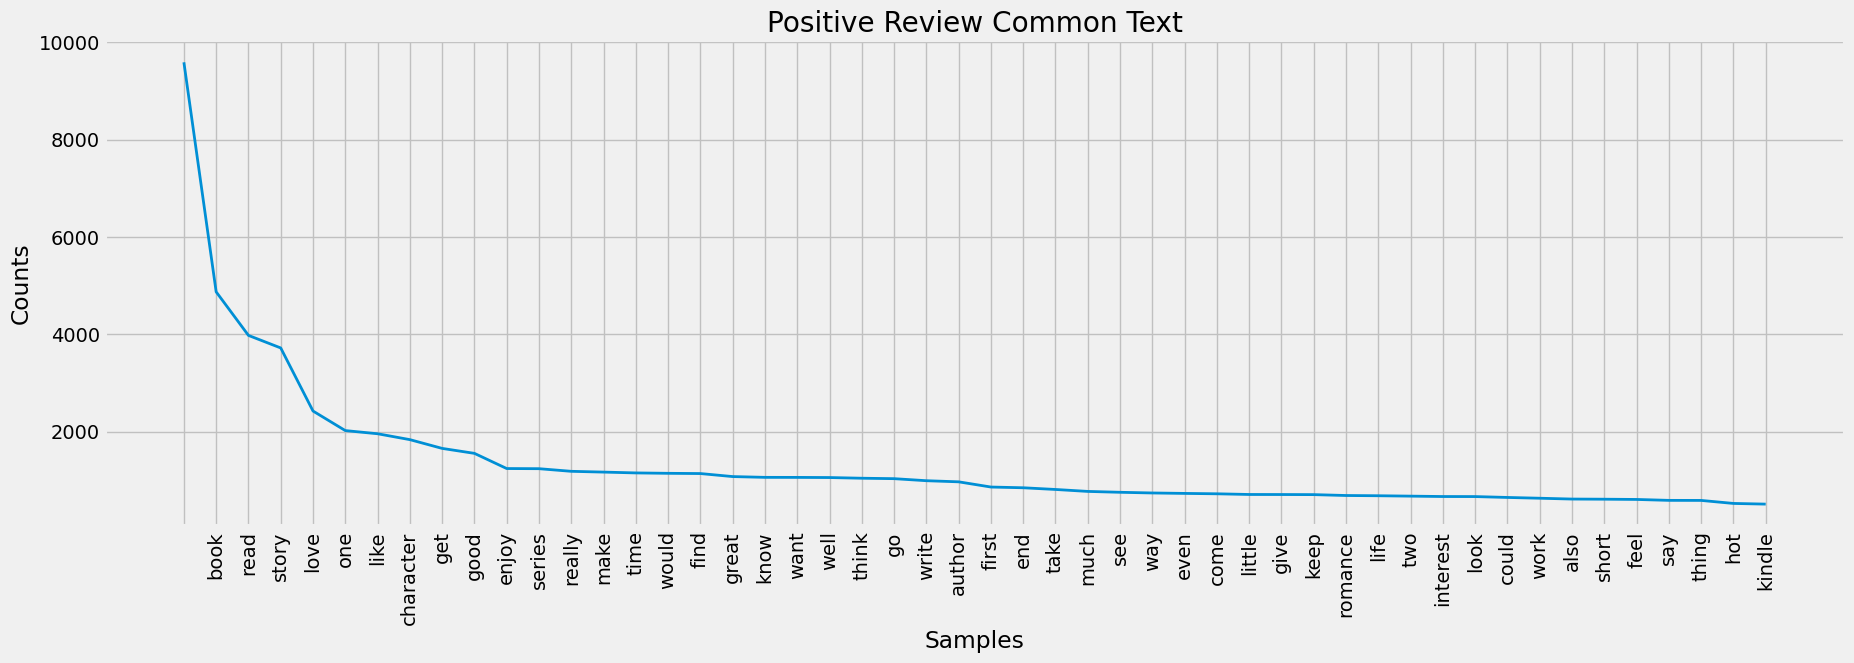

In [ ]:
# Set the figure size
plt.figure(figsize=(20, 6))

# Get the frequency distribution of words in positive reviews
pos_freq = FreqDist(' '.join(train_set[train_set['sentiment'] == 1].reviewText).split(' '))

# Plot the 50 most common words in the frequency distribution
pos_freq.plot(50, cumulative=False, title='Positive Review Common Text')

# Show the plot
plt.show()

Building The Model

In [ ]:
#Building Model

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()

tokenizer.fit_on_texts(train_x)

train_x = tokenizer.texts_to_sequences(train_x)
valid_x = tokenizer.texts_to_sequences(valid_x)
test_x = tokenizer.texts_to_sequences(test_x)

train_x = pad_sequences(train_x, maxlen=120)
valid_x = pad_sequences(valid_x, maxlen=120)
test_x = pad_sequences(test_x, maxlen=120)


In [ ]:
# Compute the size of vocabulary
size_of_vocabulary = len(tokenizer.word_index) + 1

# Print the size of vocabulary
print("The size of vocabulary:", size_of_vocabulary)


The size of vocabulary: 31164


In [ ]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, Bidirectional, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2

# Initialize a sequential model
model = Sequential()

model.add(Embedding(input_dim=size_of_vocabulary, output_dim=128, input_length=120))

model.add(Bidirectional(LSTM(units=64, return_sequences=True, dropout=0.2)))

model.add(GlobalMaxPooling1D())

model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.07)))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.07)))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.07)))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.07)))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.07)))


model.add(Dropout(rate=0.05))

model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)

model.summary()


Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_7 (Embedding)     (None, 120, 128)          3988992   
                                                                 
 bidirectional_7 (Bidirecti  (None, 120, 128)          98816     
 onal)                                                           
                                                                 
 global_max_pooling1d_7 (Gl  (None, 128)               0         
 obalMaxPooling1D)                                               
                                                                 
 dense_42 (Dense)            (None, 32)                4128      
                                                                 
 dense_43 (Dense)            (None, 32)                1056      
                                                                 
 dense_44 (Dense)            (None, 32)               

Training the model

In [ ]:
#training model
history = model.fit(train_x, train_y, batch_size=128, epochs=4,
                    validation_data=(valid_x, valid_y), verbose=1, callbacks=[mc])


Epoch 1/4
66/66 [==============================] - ETA: 0s - loss: 9.3958 - accuracy: 0.6293
Epoch 1: val_accuracy improved from -inf to 0.74444, saving model to best_model.h5
66/66 [==============================] - 15s 144ms/step - loss: 9.3958 - accuracy: 0.6293 - val_loss: 6.2800 - val_accuracy: 0.7444
Epoch 2/4
66/66 [==============================] - ETA: 0s - loss: 4.5067 - accuracy: 0.7576
Epoch 2: val_accuracy improved from 0.74444 to 0.78000, saving model to best_model.h5
66/66 [==============================] - 7s 103ms/step - loss: 4.5067 - accuracy: 0.7576 - val_loss: 3.0945 - val_accuracy: 0.7800
Epoch 3/4
66/66 [==============================] - ETA: 0s - loss: 2.2423 - accuracy: 0.8485
Epoch 3: val_accuracy improved from 0.78000 to 0.79111, saving model to best_model.h5
66/66 [==============================] - 7s 113ms/step - loss: 2.2423 - accuracy: 0.8485 - val_loss: 1.6715 - val_accuracy: 0.7911
Epoch 4/4
66/66 [==============================] - ETA: 0s - loss: 1.226

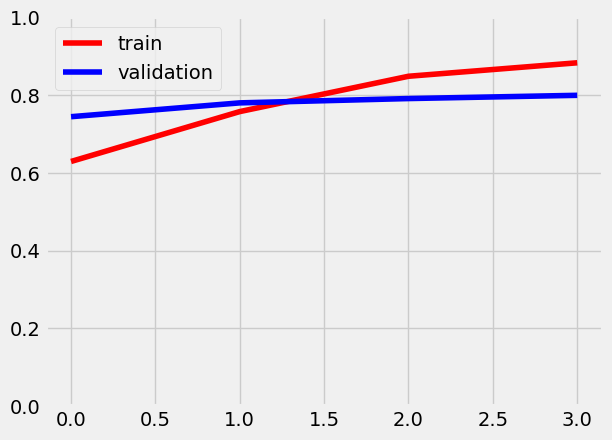

In [ ]:
import matplotlib.pyplot as plt
#Plot between train accuracy and validation accuracy

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.ylim(0, 1)
plt.show()

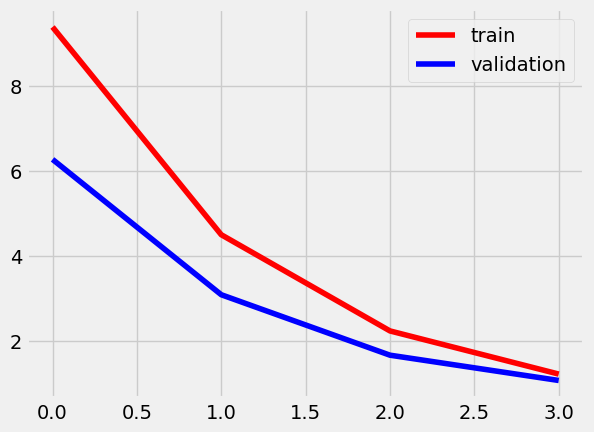

In [ ]:
#Plot between train loss and validation loss

plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

# Evaluating the model

In [ ]:
# Evaluating the model on test data
loss, accuracy = model.evaluate(test_x, test_y)

print('Test Accuracy: {}%'.format(accuracy * 100))


57/57 [==============================] - 0s 8ms/step - loss: 1.0626 - accuracy: 0.8056
Test Accuracy: 80.55555820465088%


# Result and Prediction

In [ ]:
# Predict test set sentiment values
ypred = model.predict(test_x)

ypred[ypred>0.5]=1
ypred[ypred<=0.5]=0
print(confusion_matrix(test_y,ypred))

57/57 [==============================] - 3s 9ms/step
[[739 146]
 [204 711]]


57/57 [==============================] - 0s 7ms/step


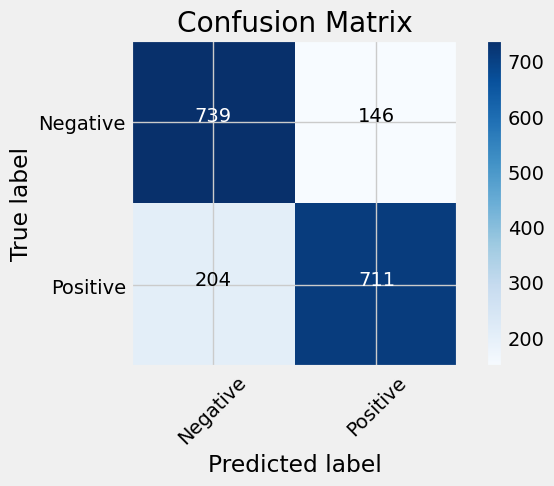

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import itertools

# Make predictions on the test set
ypred = model.predict(test_x)
ypred[ypred > 0.5] = 1
ypred[ypred <= 0.5] = 0

cm = confusion_matrix(test_y, ypred)

classes = ["Negative", "Positive"]

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


57/57 [==============================] - 0s 8ms/step


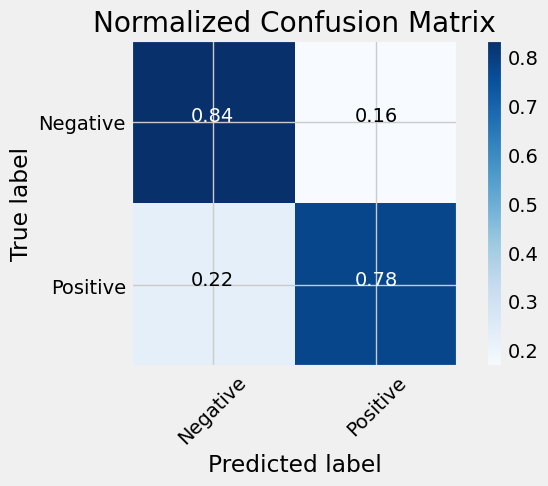

In [ ]:
# Make predictions on the test set
ypred = model.predict(test_x)
ypred[ypred > 0.5] = 1
ypred[ypred <= 0.5] = 0

cm = confusion_matrix(test_y, ypred)

classes = ["Negative", "Positive"]

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Normalized Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm_normalized.max() / 2.
for i, j in itertools.product(range(cm_normalized.shape[0]), range(cm_normalized.shape[1])):
    plt.text(j, i, format(cm_normalized[i, j], '.2f'),
             horizontalalignment="center",
             color="white" if cm_normalized[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()



In [ ]:
# Print the classification Report
print(classification_report(test_y,ypred))

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       885
           1       0.83      0.78      0.80       915

    accuracy                           0.81      1800
   macro avg       0.81      0.81      0.81      1800
weighted avg       0.81      0.81      0.81      1800



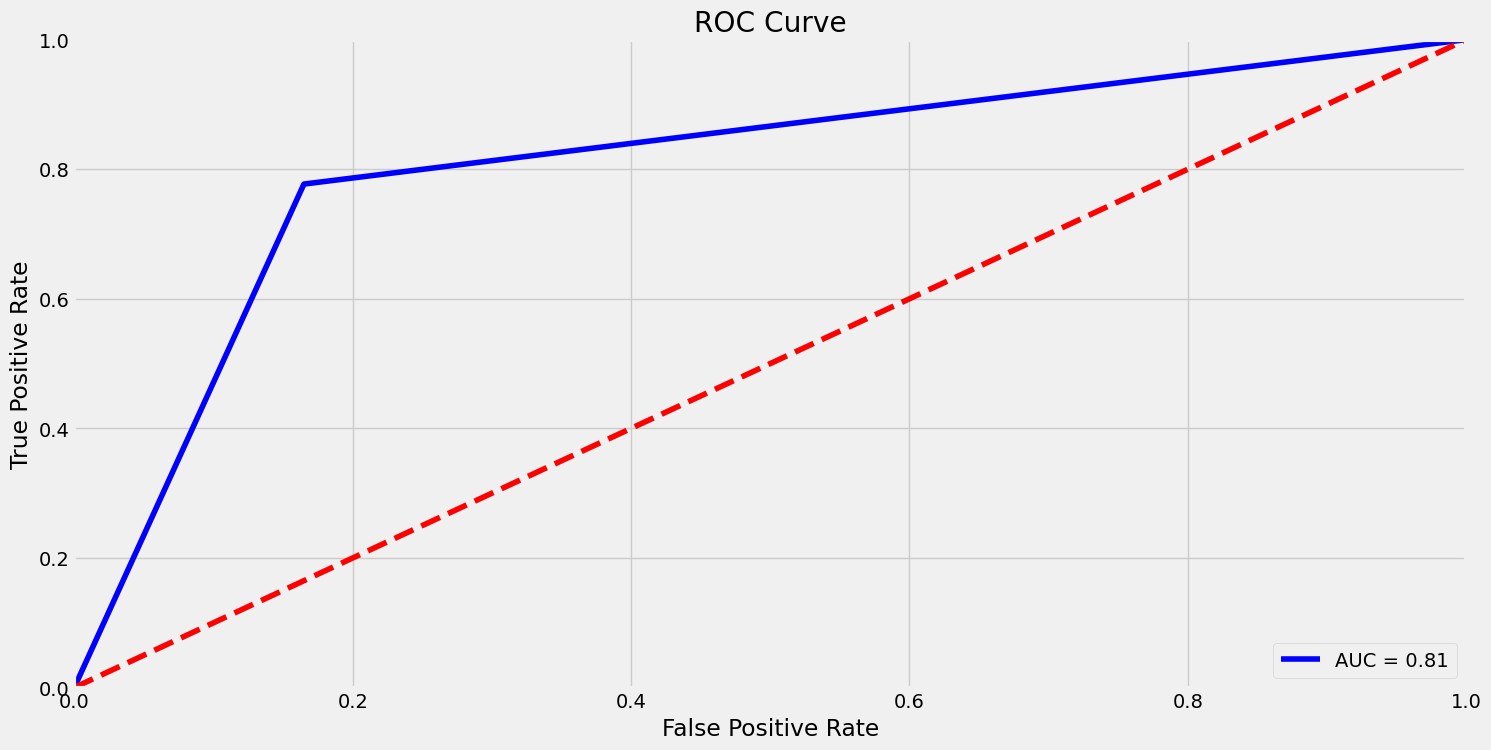

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(test_y, ypred)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(16,8))

plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)

plt.plot([0, 1], [0, 1],'r--')

plt.xlim([0, 1])
plt.ylim([0, 1])

plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.title('ROC Curve')

plt.legend(loc = 'lower right')

plt.show()


The AUC value, which ranges from 1 (perfect) to 0.5 (random guessing), indicates how well a model performs overall. As can be seen, the model performs quite well with an AUC of 0.89. The random classifier line (red dashed line) lies below the ROC curve (blue line), indicating that our model performs better than a random guess. Since the curve is in the top-left corner, it signifies good performance and shows the balance between the real positive rate and false positive rate.